## Data Loading

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Preprocessing & Feature Engineering Pipeline

A preprocessing function is implemented to streamline the data transformation process. This modular approach allows for rapid experimentation with different feature sets and ensures consistency between training and testing data.

In [ ]:
def preprocess_data(df):

    df_new = df.copy()

    # Feature Engineering: Extract Titles from passenger names
    # This helps distinguish social status and identifies children (Master) separately from adult males.
    df_new["Title"] = df_new["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

    # Consolidate rare titles to reduce noise and prevent overfitting
    rare_titles = [
        "Lady",
        "Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ]
    df_new["Title"] = df_new["Title"].replace(rare_titles, "Rare")

    # Standardize French and common abbreviations to English equivalents
    df_new["Title"] = df_new["Title"].replace(["Mlle", "Ms"], "Miss")
    df_new["Title"] = df_new["Title"].replace("Mme", "Mrs")

    # Feature Engineering: Family Size
    df_new["FamilySize"] = df_new["SibSp"] + df_new["Parch"] + 1

    # Handling Missing Values
    # Impute missing Age and Fare with median values to minimize the impact of outliers.
    df_new["Age"] = df_new["Age"].fillna(df_new["Age"].median())
    df_new["Fare"] = df_new["Fare"].fillna(df_new["Fare"].median())

    # Encoding Categorical Variables
    df_new["Sex"] = df_new["Sex"].replace({"female": 0, "male": 1})
    df_new = pd.get_dummies(df_new, columns=["Title"], drop_first=True)

    # Feature Selection
    # Identify all newly created Title columns
    title_features = [col for col in df_new.columns if col.startswith("Title_")]
    base_features = ["Pclass", "Sex", "Age", "FamilySize", "Fare"]

    final_features = base_features + title_features

    return df_new[final_features]

## Data Acquisition and Initial Exploration

This allows for an understanding of the available features, data types, and any immediate issues such as missing values or structural inconsistencies.

In [4]:
train_data = pd.read_csv("train.csv")
print("--- Table info ---")
print(train_data.info())
display(train_data.head())

--- Table info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The initial data overview identified gaps in several features, most notably 'Age', 'Cabin', and 'Embarked'. Standard machine learning implementations, such as the Random Forest classifier in Scikit-Learn, are unable to process datasets containing null values (NaNs). To prevent execution errors and ensure the estimator can derive patterns from every available observation, an imputation strategy was integrated directly into the preprocessing function

## EDA & Feature Engineering

#### Hypothesis Verification: Gender and Socio-Economic Status

Before proceeding to model training, it is essential to verify fundamental assumptions regarding the features. Historical accounts suggest that survival was strongly correlated with gender ("women and children first") and wealth (represented by passenger class). These simple correlations serve as a baseline for understanding the dataset's predictive structure.

In [ ]:
# Add the age groups to see if distribution of survival rate is different in the group of children
train_data["AgeGroup"] = pd.cut(train_data["Age"], [0, 18, 80])
result_table = train_data.pivot_table(
    values="Survived",
    index=["Sex", "AgeGroup"],
    columns="Pclass",
    observed=False,
    margins=True,
    margins_name="Total",
)
display(result_table)
# The age group for model training is not necessary (continious data works better)
train_data.drop("AgeGroup", axis=1, inplace=True)

Pclass                  1         2         3     Total
Sex    AgeGroup                                        
female (0, 18]   0.909091  1.000000  0.511628  0.676471
       (18, 80]  0.972973  0.900000  0.423729  0.782383
male   (0, 18]   0.800000  0.600000  0.215686  0.338028
       (18, 80]  0.375000  0.071429  0.133663  0.180628
Total            0.655914  0.479769  0.239437  0.406162

#### Initial Findings:
* **Gender Bias**: Female passengers show a significantly higher survival rate compared to males, confirming that 'Sex' is likely the most dominant predictive feature.
* **Socio-Economic Impact**: A clear trend is visible where 1st-class passengers had prioritized access to lifeboats, whereas 3rd-class passengers faced the lowest survival probabilities.
* **Priority for Children**: Younger passengers, particularly those under the age of 18, show a statistically higher survival rate across most classes compared to adult males.

#### Hypothesis Verification: Family Dynamics and Group Survival

Another critical factor to examine is the impact of family size on survival. Traveling with family members could be a double-edged sword: while it might provide a support network (especially for males), large groups might have faced logistical difficulties and emotional distress during the chaotic evacuation process. By analyzing `FamilySize`, we can determine if being part of a group was an advantage or a hindrance.

Survival Statistics by Declared Family Size:
 FamilySize  PassengerCount  SurvivalPercentage
          1             537               30.35
          2             161               55.28
          3             102               57.84
          4              29               72.41
          5              15               20.00
          6              22               13.64
          7              12               33.33
          8               6                0.00
         11               7                0.00


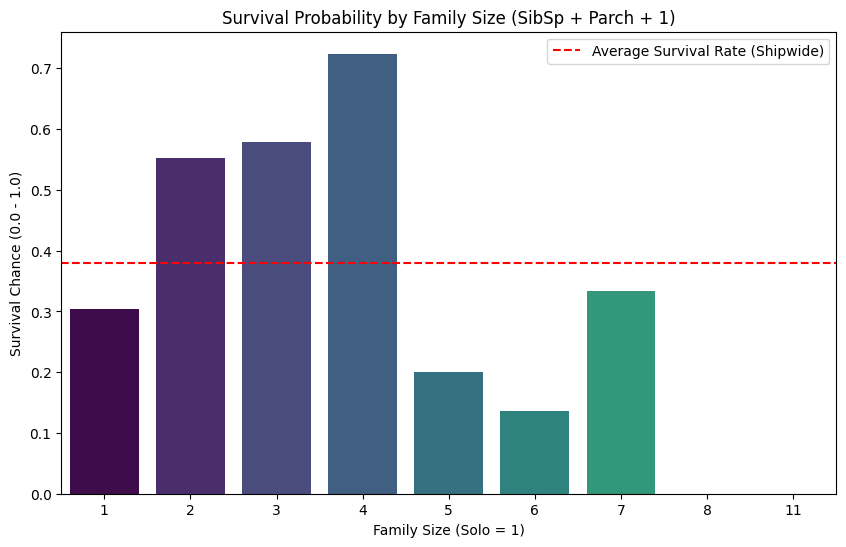

In [ ]:
def analyze_family_size(df):

    analysis_df = df.copy()  # Prevents modification of the original dataset

    # Calculate FamilySize
    analysis_df["FamilySize"] = analysis_df["SibSp"] + analysis_df["Parch"] + 1

    # Aggregate statistics: Count of passengers and mean survival rate per group size
    family_stats = (
        analysis_df.groupby("FamilySize")["Survived"]
        .agg(["count", "mean"])
        .reset_index()
    )
    family_stats.columns = ["FamilySize", "PassengerCount", "SurvivalRate"]
    family_stats["SurvivalPercentage"] = (family_stats["SurvivalRate"] * 100).round(2)

    return family_stats, analysis_df


# Generate statistics and processed dataframe
stats, processed_df = analyze_family_size(train_data)

print("Survival Statistics by Declared Family Size:")
print(
    stats[["FamilySize", "PassengerCount", "SurvivalPercentage"]].to_string(index=False)
)

# Visualization of survival rates relative to the ship's average
plt.figure(figsize=(10, 6))
sns.barplot(
    x="FamilySize",
    y="SurvivalRate",
    data=stats,
    hue="FamilySize",
    palette="viridis",
    legend=False,
)

# Reference line representing the overall average survival rate as a cut-off (~38%)
plt.axhline(0.38, color="red", linestyle="--", label="Average Survival Rate (Shipwide)")

plt.title("Survival Probability by Family Size (SibSp + Parch + 1)")
plt.ylabel("Survival Chance (0.0 - 1.0)")
plt.xlabel("Family Size (Solo = 1)")
plt.legend()
plt.show()

The relationship between family size and survival is not straightforward. While a general trend favors small families, there are nuances that require careful interpretation:

* **Statistical Noise in Large Groups**: A survival peak is observed for families of 7. However, it is crucial to note that the sample size for large families (5, 6, 7+ members) is significantly smaller. The survival of even a few individuals in these groups leads to a disproportionately high survival percentage, which may not represent a reliable trend.
* **Non-Linear Correlation**: The data suggests a non-linear relationship. Since standard heatmaps typically utilize the **Pearson Correlation Coefficient**, which measures linear strength, this specific dynamic might appear weak or stay hidden in a correlation matrix.

#### Pairwise Correlation Analysis

To understand the relationships between our selected features and the target variable, we calculate the absolute Pearson correlation coefficients. This visualization helps identify which variables have the strongest linear association with survival and flags potential multi-collinearity between independent features.

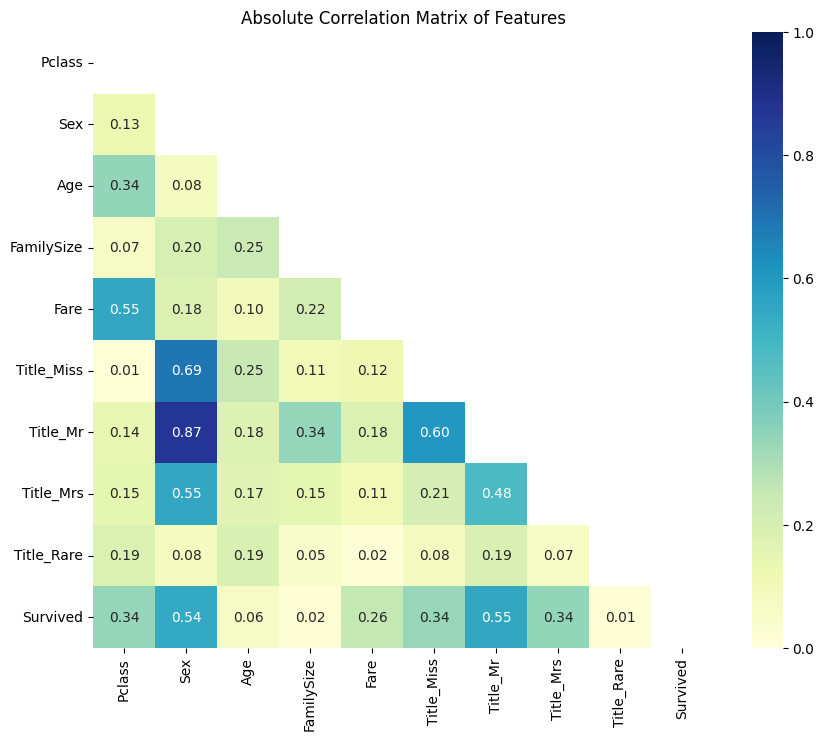

In [ ]:
# Suppress the specific downcasting warning to keep the output clean
pd.set_option("future.no_silent_downcasting", True)

# Preprocess data to ensure consistency across features
df_numeric = preprocess_data(train_data)

# Re-attach the target 'Survived' for correlation analysis (it was excluded during preprocessing)
df_numeric["Survived"] = train_data["Survived"]

# Calculate absolute correlation values
# We focus on the strength of the relationship rather than the direction
corr_abs = df_numeric.corr().abs()

# Generate a mask to hide the upper triangle for better readability
mask = np.triu(np.ones_like(corr_abs, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_abs, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Absolute Correlation Matrix of Features")
plt.show()

#### Key Insights from the Refined Correlation Matrix
With the introduction of Title-based features, the correlation matrix now provides a more granular view of the survival dynamics:

* **The "Mr" Penalty**: Title_Mr shows the strongest negative correlation with survival (around -0.55). This confirms that being an adult male was the single most significant risk factor, even more descriptive than the general Sex category alone.

* **Strong Collinearity with Sex**: As expected, Title_Mr and Sex show a naturally high correlation (0.87), as do Title_Miss and Title_Mrs with the female gender.

* **Socio-Economic Signifiers**: Fare continues to correlate strongly with Pclass (-0.55)

#### Dimensionality Reduction with PCA

To better understand the internal structure of our feature space and identify latent patterns, Principal Component Analysis (PCA) was applied. Before decomposition, features are standardized using `StandardScaler` to ensure that variables with different ranges (e.g., `Age` vs `Fare`) contribute equally to the analysis.

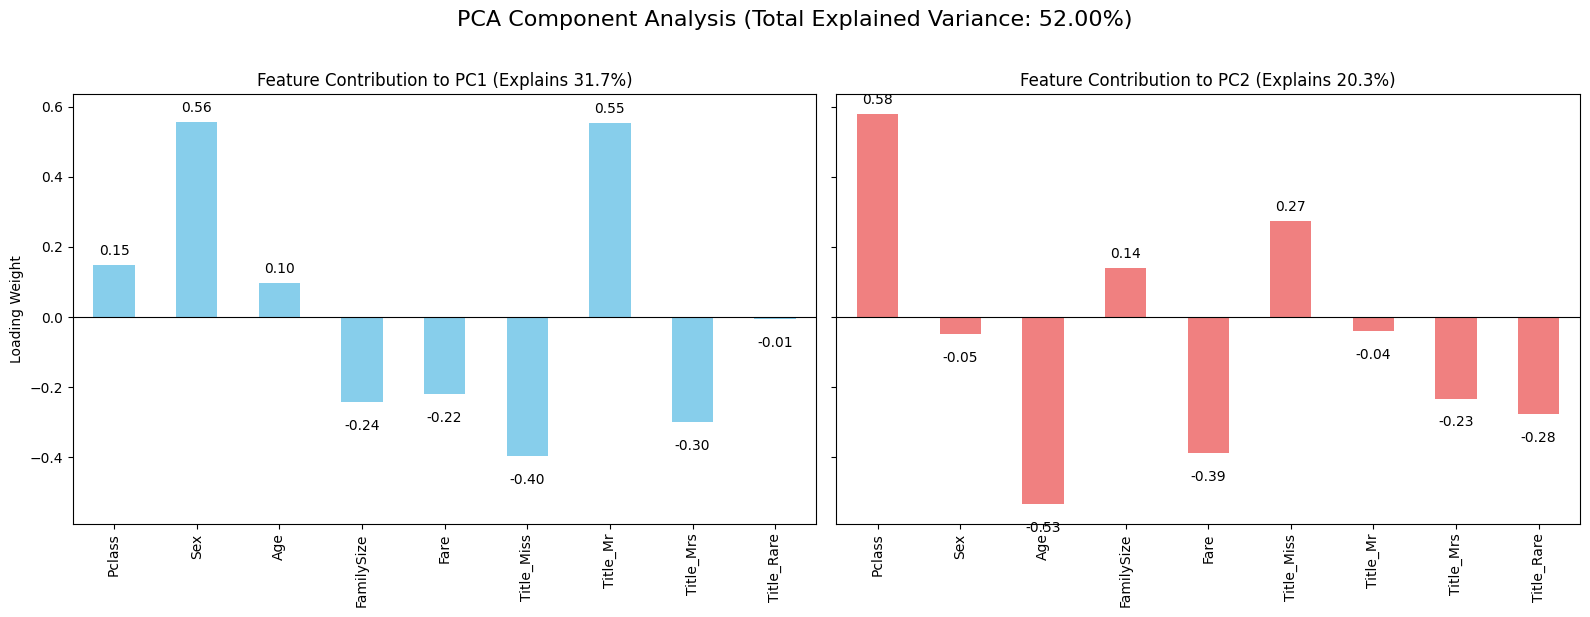

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Data preparation using the modular preprocessing function
X_pca_input = preprocess_data(train_data)

# Standardization: Scaling features to unit variance for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

# Applying PCA for the first two principal components
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Creating a DataFrame to analyze feature loadings for each component
loadings = pd.DataFrame(
    pca.components_, columns=X_pca_input.columns, index=["PC1", "PC2"]
)
ratios = pca.explained_variance_ratio_

# Visualization of Component Loadings
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
colors = ["skyblue", "lightcoral"]
fig.suptitle(
    f"PCA Component Analysis (Total Explained Variance: {sum(ratios):.2%})",
    fontsize=16,
    y=1.02,
)

for i, ax in enumerate(axes):
    pc_name = f"PC{i + 1}"
    loadings.loc[pc_name].plot(kind="bar", ax=ax, color=colors[i])

    ax.set_title(f"Feature Contribution to {pc_name} (Explains {ratios[i]:.1%})")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("Loading Weight")

    # Adding text labels for precise loading values
    for p in ax.patches:
        val = p.get_height()
        ax.annotate(
            f"{val:.2f}",
            (p.get_x() + p.get_width() / 2.0, val),
            ha="center",
            va="bottom" if val > 0 else "top",
            xytext=(0, 5 if val > 0 else -12),
            textcoords="offset points",
            fontsize=10,
        )

plt.tight_layout()
plt.show()

#### Analysis of Variance and Data Complexity

* **Information Retention**: Capturing **52.00%** of the total variance with only two components is a strong result for a dataset with such high human variability. 

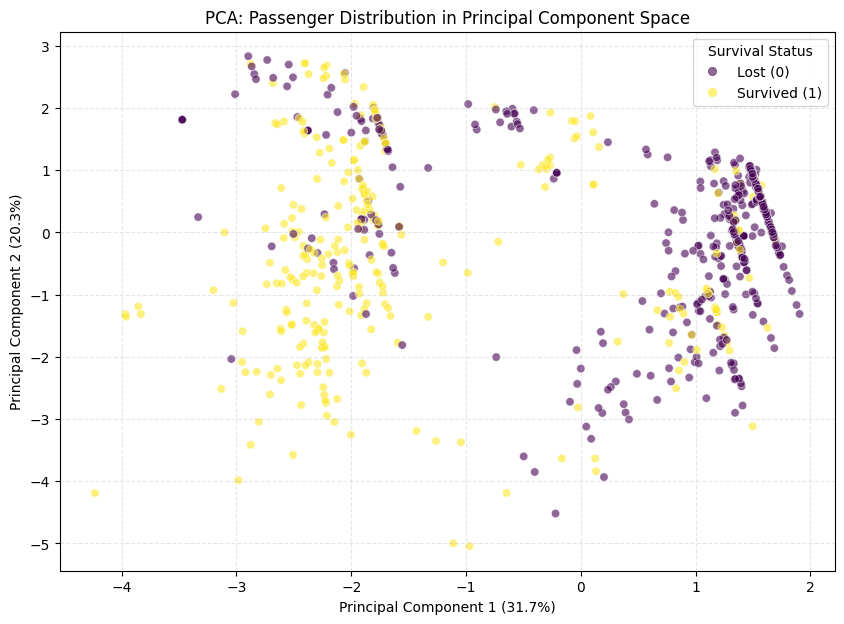

In [ ]:
plt.figure(figsize=(10, 7))

# Scatter plot of the two principal components
# Color is defined by target ('Survived')
scatter = plt.scatter(
    components[:, 0],
    components[:, 1],
    c=train_data["Survived"],
    alpha=0.6,
    cmap="viridis",
    edgecolors="white",
    linewidth=0.5,
)

# Creating a legend for the survival status
handles, labels = scatter.legend_elements()
legend = plt.legend(
    handles, ["Lost (0)", "Survived (1)"], title="Survival Status", loc="upper right"
)

plt.title("PCA: Passenger Distribution in Principal Component Space")
plt.xlabel(f"Principal Component 1 ({ratios[0]:.1%})")
plt.ylabel(f"Principal Component 2 ({ratios[1]:.1%})")
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

#### PCA Interpretation: Mapping Social Structures

* **PC1 (31.7% Variance) — "The Gender & Status Axis"**:

This axis primarily divides passengers by gender and social role. 
Positive values (right side) are heavily driven by Sex_male and Title_Mr.
Negative values (left side) gravitate toward female titles like Title_Miss and Title_Mrs.
The scatterplot shows two distinct clusters. The right side is almost entirely purple (Lost), representing the adult male group. The left side is saturated with yellow points (Survived), representing women and children.

* **PC2 (20.3% Variance) — "The Class & Age Axis"**:

This axis focuses on socio-economic and demographic position.
Positive values (top) are determined by Pclass (specifically 3rd class).
Negative values (bottom) correspond to higher Age and larger Fare (wealthier, older passengers).

On the scatterplot within each gender group, we see vertical stratification. Among women (left), survivors are more concentrated toward the bottom (wealthier/older), while fatalities occur more frequently toward the top (lower-class/younger).

Diagonal Structures: The presence of clear "streaks" or "lines" indicates that the data is discrete (classes, titles). 

## Modeling & Evaluation

#### Hyperparameter Tuning and Cross-Validation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import metrics

# Feature and Target selection
X = preprocess_data(train_data)
y = train_data["Survived"]

# Split data: 80% for training, 20% for validation
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=0)

# Hyperparameter Grid: Optimizing forest structure
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 8, 10],
    "min_samples_leaf": [1, 2, 4],
}

# Search Setup: Using all available cores (n_jobs=-1)
rf = RandomForestClassifier(random_state=0)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2
)

# Training Process
grid_search.fit(Xtrain, ytrain)

# Output results
print("-" * 30)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2%}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ..max_depth=5, min_samples_leaf=2, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=2, n_estimators=100; total time=   0.1s[CV] END ..max_depth=5, min_samples_leaf=2, n_estimators=100; total time=   0.2s

[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=5, min_samples_leaf=2, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=1, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=5, min_samples_leaf=2, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=5, min_samples_leaf=4, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=5, min_samples_leaf=4, n_e

#### Final Model Evaluation

In [30]:
best_model = grid_search.best_estimator_
ypred = best_model.predict(Xtest)

print("\nFinal Model Evaluation Report:")
print(metrics.classification_report(ytest, ypred))

test_accuracy = metrics.accuracy_score(ytest, ypred)
print(f"Overall Test Accuracy: {test_accuracy:.2%}")


Final Model Evaluation Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       110
           1       0.86      0.71      0.78        69

    accuracy                           0.84       179
   macro avg       0.85      0.82      0.83       179
weighted avg       0.85      0.84      0.84       179

Overall Test Accuracy: 84.36%


#### Analysis of Feature Importance

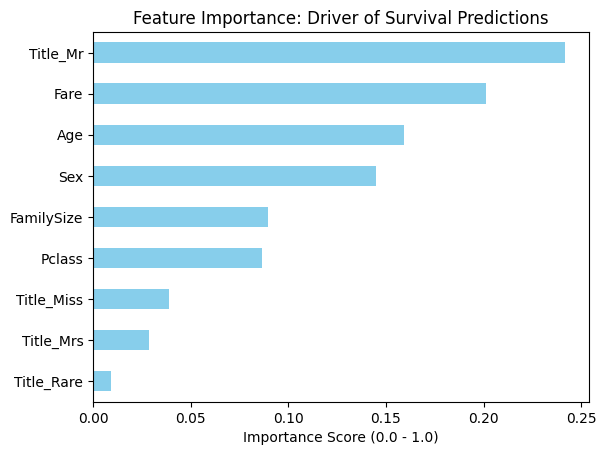

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)

# Sort and visualize the contribution of each feature
importances.sort_values().plot(kind="barh", color="skyblue")

plt.title("Feature Importance: Driver of Survival Predictions")
plt.xlabel("Importance Score (0.0 - 1.0)")
plt.show()


#### Training Set Error Analysis

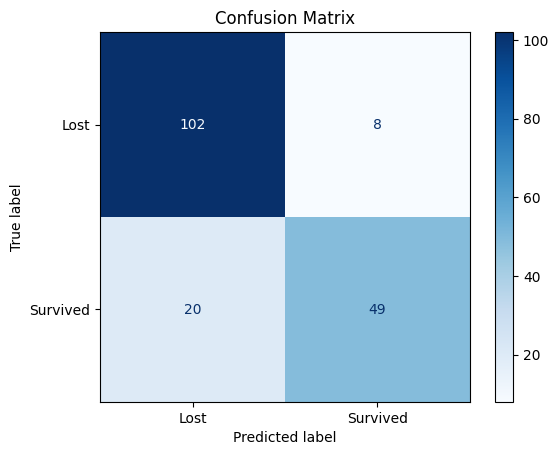

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(ytest, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Lost", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1

# Aligning original metadata with the test results using indices
errors_df = train_data.loc[Xtest.index].copy()
errors_df["Predicted"] = ypred
errors_df["Actual"] = ytest

# Filter for instances where predictions do not match actual survival outcomes
mismatches = errors_df[errors_df["Predicted"] != errors_df["Actual"]]

# Define columns for a clear view
cols_to_show = ["Name", "Sex", "Pclass", "Age", "FamilySize", "Fare"]

# 1. Unexpected Fatalities (False Positives)
print("Unexpected Fatalities (Predicted 1, Actual 0):")
display(mismatches[mismatches["Actual"] == 0][cols_to_show].head())

# 2. Miraculous Survivals (False Negatives)
print("\nMiraculous Survivals (Predicted 0, Actual 1):")
display(mismatches[mismatches["Actual"] == 1][cols_to_show].head())

Unexpected Fatalities (Predicted 1, Actual 0):


,Name,Sex,Pclass,Age,FamilySize,Fare
14,"Vestrom, Miss. Hulda Amanda Adolfina",female,3,14.0,1,7.8542
848,"Harper, Rev. John",male,2,28.0,2,33.0000
312,"Lahtinen, Mrs. William (Anna Sylfven)",female,2,26.0,3,26.0000
694,"Weir, Col. John",male,1,60.0,1,26.5500
251,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,3,29.0,3,10.4625



Miraculous Survivals (Predicted 0, Actual 1):


,Name,Sex,Pclass,Age,FamilySize,Fare
255,"Touma, Mrs. Darwis (Hanne Youssef Razi)",female,3,29.0,3,15.2458
298,"Saalfeld, Mr. Adolphe",male,1,NaN,1,30.5000
484,"Bishop, Mr. Dickinson H",male,1,25.0,2,91.0792
55,"Woolner, Mr. Hugh",male,1,NaN,1,35.5000
632,"Stahelin-Maeglin, Dr. Max",male,1,32.0,1,30.5000


#### Final Error Analysis: Identifying "Data Noise"¶
The qualitative inspection of mismatches confirms that the model’s errors are primarily driven by historical "noise" rather than logical flaws:

* **Rule-Based Success**: The model correctly prioritizes young females, even from the 3rd class, because Sex is the dominant predictor.

* **Logical Fatalities**: It consistently predicts fatalities for adult males, even in the 1st class, following the "women and children first" protocol.

* **Tragic & Miraculous Outliers**: Errors like wealthy women perishing or 3rd-class men surviving represent situational chaos.

## Submission

In [22]:
test_data = pd.read_csv("test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
X_submission = preprocess_data(test_data)

predictions = best_model.predict(X_submission)

# Format the results into the required submission structure
output = pd.DataFrame({"PassengerId": test_data.PassengerId, "Survived": predictions})

# Export to CSV for Kaggle leaderboard submission
output.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' successfully created!")
print("Features used for prediction:", X_submission.columns.tolist())

Submission file 'submission.csv' successfully created!
Features used for prediction: ['Pclass', 'Sex', 'Age', 'FamilySize', 'Fare', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


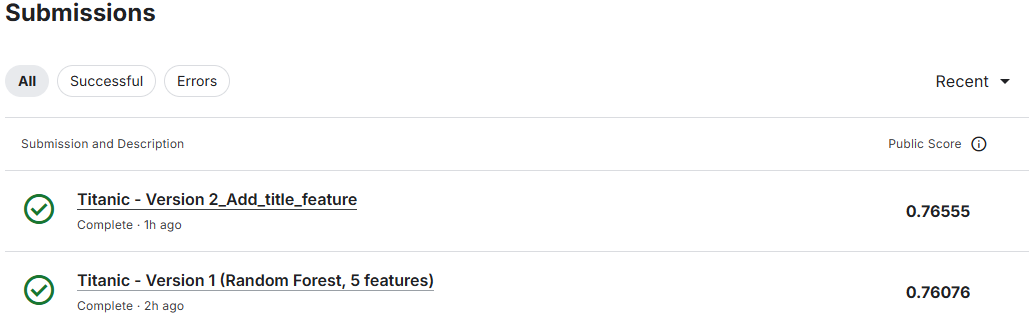